# PANN 3s / 25 Segments: MLP

This notebook trains and evaluates a multilayer perceptron classifier using precomputed PANN embeddings extracted from 25 random 3-second segments per track.

The embeddings are generated once in `13_pann_save_embeddings_3s_25.ipynb` and reused here to avoid repeated PANN inference.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import os
import sys
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import (
    PANN_3S25_EMBEDDING_FILE,
    TRAINED_MODELS_DIR,
    MODEL_RESULTS_DIR,
    RANDOM_STATE
)


In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# The embeddings are created once in PANN_25x3s_Save_Embeddings.ipynb.
# All four model notebooks load the same file to avoid repeating the expensive PANN inference step.
EMBEDDING_FILE = str(PANN_3S25_EMBEDDING_FILE)

RANDOM_STATE = RANDOM_STATE
MODEL_NAME = "PANN_3s_25_MLP"

# Output directories
trained_models_dir = str(TRAINED_MODELS_DIR)
results_dir = str(MODEL_RESULTS_DIR)

os.makedirs(trained_models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

In [ ]:
# ---------------------------------------------------------
# LOAD PRECOMPUTED PANN EMBEDDINGS
# ---------------------------------------------------------
# Run PANN_25x3s_Save_Embeddings.ipynb once before this notebook.
# This avoids extracting PANN embeddings again for every model.

if not os.path.exists(EMBEDDING_FILE):
    raise FileNotFoundError(
        f"Embedding file not found: {EMBEDDING_FILE}"
        "Please run PANN_25x3s_Save_Embeddings.ipynb first."
    )

pann_embedding_data = joblib.load(EMBEDDING_FILE)

split_features = pann_embedding_data["split_features"]
skipped_by_split = pann_embedding_data.get("skipped_by_split", {})
train_df = pann_embedding_data.get("train_df")
val_df = pann_embedding_data.get("val_df")
test_df = pann_embedding_data.get("test_df")

X_train = split_features["train"]["X"]
X_val = split_features["val"]["X"]
X_test = split_features["test"]["X"]

y_train_labels = split_features["train"]["y_labels"]
y_val_labels = split_features["val"]["y_labels"]
y_test_labels = split_features["test"]["y_labels"]

label_encoder = LabelEncoder()
if "label_classes" in pann_embedding_data:
    label_encoder.classes_ = np.asarray(pann_embedding_data["label_classes"])
else:
    label_encoder.fit(np.concatenate([y_train_labels, y_val_labels, y_test_labels]))

label_names = list(label_encoder.classes_)
label_to_idx = {label: idx for idx, label in enumerate(label_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train = label_encoder.transform(y_train_labels)
y_val = label_encoder.transform(y_val_labels)
y_test = label_encoder.transform(y_test_labels)

track_ids_train = split_features["train"]["track_ids"]
track_ids_val = split_features["val"]["track_ids"]
track_ids_test = split_features["test"]["track_ids"]
segment_ids_test = split_features["test"]["segment_ids"]
labels_test = y_test_labels

# Compatibility variables for older cells
embeddings = np.vstack([X_train, X_val, X_test])
y_true_numerical = np.concatenate([y_train, y_val, y_test])
track_ids_filtered = np.concatenate([track_ids_train, track_ids_val, track_ids_test])

print("[LOADED] Precomputed PANN embeddings")
print(f"Train embeddings: {X_train.shape}")
print(f"Val embeddings:   {X_val.shape}")
print(f"Test embeddings:  {X_test.shape}")
print(f"Classes: {list(label_encoder.classes_)}")


[LOADED] Precomputed PANN embeddings
Train embeddings: (85275, 2048)
Val embeddings:   (10650, 2048)
Test embeddings:  (10675, 2048)
Classes: [np.str_('Classical'), np.str_('Electronic'), np.str_('Folk'), np.str_('Hip-Hop'), np.str_('Jazz'), np.str_('Old-Time / Historic'), np.str_('Pop'), np.str_('Rock')]


In [7]:
# ---------------------------------------------------------
# TRAIN / VALIDATION / TEST SPLIT SUMMARY
# ---------------------------------------------------------
# The split was already performed on track level before feature extraction.
# Therefore, all random 3-second segments of one track stay in the same split.

print(f"Train samples: {len(X_train)} | Validation samples: {len(X_val)} | Test samples: {len(X_test)}")

if train_df is not None and val_df is not None and test_df is not None:
    print(f"Train tracks: {len(train_df)} | Validation tracks: {len(val_df)} | Test tracks: {len(test_df)}")
else:
    print(f"Train tracks: {len(np.unique(track_ids_train))} | Validation tracks: {len(np.unique(track_ids_val))} | Test tracks: {len(np.unique(track_ids_test))}")

print("Skipped tracks by split:", skipped_by_split)


Train samples: 85275 | Validation samples: 10650 | Test samples: 10675
Train tracks: 3411 | Validation tracks: 426 | Test tracks: 427
Skipped tracks by split: {'train': 0, 'val': 0, 'test': 0}


In [8]:
# ---------------------------------------------------------
# FEATURE SCALING
# ---------------------------------------------------------

# Use RobustScaler (less sensitive to outliers)
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n--- Data split & scaling completed ---")
print(f"Train: {len(X_train_scaled)}, Val: {len(X_val_scaled)}, Test: {len(X_test_scaled)}")


--- Data split & scaling completed ---
Train: 85275, Val: 10650, Test: 10675


In [9]:
# ---------------------------------------------------------
# SANITY CHECK
# ---------------------------------------------------------

# Ensure scaled datasets exist (from previous preprocessing cell)
try:
    if 'X_train_scaled' not in locals():
        print("ERROR: Scaled data not found. Please run the preprocessing cell first.")
        sys.exit()
except NameError:
    print("ERROR: Scaled data not found. Please run the preprocessing cell first.")
    sys.exit()

In [ ]:
# ---------------------------------------------------------
# COMMON EVALUATION AND EXPORT HELPERS
# ---------------------------------------------------------

os.makedirs(trained_models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)


def evaluate_model(model, X_data, y_true, set_name, label_encoder):
    """Evaluate a trained model on segment level and plot the confusion matrix."""
    y_pred = model.predict(X_data)

    print(f"\n======== SEGMENT-LEVEL EVALUATION: {set_name} ========")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(label_encoder.classes_)))
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel(f"Predicted Label ({set_name})")
    plt.ylabel(f"True Label ({set_name})")
    plt.title(f"Segment-Level Confusion Matrix ({set_name})")
    plt.show()

    return y_pred


def _mode_int(values):
    """Return the most frequent integer value. If there is a tie, the smallest class index is used."""
    counts = pd.Series(values).value_counts()
    max_count = counts.max()
    return int(counts[counts == max_count].index.min())


def evaluate_track_level(model, X_data, y_true, track_ids, set_name, label_encoder, output_name):
    """
    Aggregate segment predictions to track-level predictions.

    Two aggregation strategies are calculated:
    1. Majority voting over predicted segment classes.
    2. Mean probabilities if the model supports predict_proba; otherwise mean decision scores.

    This evaluates each track exactly once, instead of counting all 25 segments separately.
    """
    y_segment_pred = model.predict(X_data)

    segment_df = pd.DataFrame({
        "track_id": track_ids,
        "true_label": y_true,
        "segment_pred": y_segment_pred
    })

    # One true label per track. The mode is used defensively in case duplicated rows exist.
    true_track = segment_df.groupby("track_id")["true_label"].agg(_mode_int)

    # -----------------------------------------------------
    # 1) Majority voting over segment predictions
    # -----------------------------------------------------
    majority_pred = segment_df.groupby("track_id")["segment_pred"].agg(_mode_int)

    majority_results = pd.DataFrame({
        "track_id": true_track.index,
        "true_label": true_track.values,
        "predicted_label": majority_pred.loc[true_track.index].values
    })
    majority_results["true_genre"] = label_encoder.inverse_transform(majority_results["true_label"].to_numpy())
    majority_results["predicted_genre"] = label_encoder.inverse_transform(majority_results["predicted_label"].to_numpy())

    print(f"\n======== TRACK-LEVEL EVALUATION: {set_name} | Majority Voting ========")
    print("Accuracy:", accuracy_score(majority_results["true_label"], majority_results["predicted_label"]))
    print("Balanced Accuracy:", balanced_accuracy_score(majority_results["true_label"], majority_results["predicted_label"]))
    print("Macro F1:", f1_score(majority_results["true_label"], majority_results["predicted_label"], average="macro"))
    print("\nClassification Report:")
    print(classification_report(
        majority_results["true_label"],
        majority_results["predicted_label"],
        labels=np.arange(len(label_encoder.classes_)),
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    majority_out = os.path.join(
        results_dir,
        f"{output_name}_{set_name.lower()}_track_level_majority_voting.csv"
    )
    majority_results.to_csv(majority_out, index=False)

    majority_misclassified = majority_results[
        majority_results["true_label"] != majority_results["predicted_label"]
    ][["track_id", "true_genre", "predicted_genre"]]
    majority_mis_out = os.path.join(
        results_dir,
        f"{output_name}_{set_name.lower()}_misclassified_tracks_majority_voting.csv"
    )
    majority_misclassified.to_csv(majority_mis_out, index=False)
    print(f"Saved majority-voting track predictions to: {majority_out}")
    print(f"Saved majority-voting track-level misclassifications to: {majority_mis_out}")

    # -----------------------------------------------------
    # 2) Mean probabilities or mean decision scores
    # -----------------------------------------------------
    mean_results = None

    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_data)
        score_type = "mean_probability"
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        score_type = "mean_decision_score"

        # Binary decision_function can return one score. Convert to two columns if needed.
        if scores.ndim == 1:
            scores = np.column_stack([-scores, scores])
    else:
        scores = None
        score_type = None

    if scores is not None:
        score_cols = [f"score_{class_name}" for class_name in label_encoder.classes_]
        score_df = pd.DataFrame(scores, columns=score_cols)
        score_df["track_id"] = track_ids

        mean_scores = score_df.groupby("track_id")[score_cols].mean().loc[true_track.index]
        mean_pred = np.argmax(mean_scores.to_numpy(), axis=1)

        mean_results = pd.DataFrame({
            "track_id": true_track.index,
            "true_label": true_track.values,
            "predicted_label": mean_pred
        })
        mean_results["true_genre"] = label_encoder.inverse_transform(mean_results["true_label"].to_numpy())
        mean_results["predicted_genre"] = label_encoder.inverse_transform(mean_results["predicted_label"].to_numpy())

        print(f"\n======== TRACK-LEVEL EVALUATION: {set_name} | {score_type} ========")
        print("Accuracy:", accuracy_score(mean_results["true_label"], mean_results["predicted_label"]))
        print("Balanced Accuracy:", balanced_accuracy_score(mean_results["true_label"], mean_results["predicted_label"]))
        print("Macro F1:", f1_score(mean_results["true_label"], mean_results["predicted_label"], average="macro"))
        print("\nClassification Report:")
        print(classification_report(
            mean_results["true_label"],
            mean_results["predicted_label"],
            labels=np.arange(len(label_encoder.classes_)),
            target_names=label_encoder.classes_,
            zero_division=0
        ))

        mean_out = os.path.join(
            results_dir,
            f"{output_name}_{set_name.lower()}_track_level_{score_type}.csv"
        )
        mean_results.to_csv(mean_out, index=False)

        mean_misclassified = mean_results[
            mean_results["true_label"] != mean_results["predicted_label"]
        ][["track_id", "true_genre", "predicted_genre"]]
        mean_mis_out = os.path.join(
            results_dir,
            f"{output_name}_{set_name.lower()}_misclassified_tracks_{score_type}.csv"
        )
        mean_misclassified.to_csv(mean_mis_out, index=False)
        print(f"Saved {score_type} track predictions to: {mean_out}")
        print(f"Saved {score_type} track-level misclassifications to: {mean_mis_out}")
    else:
        print("\n[WARN] Model does not support predict_proba or decision_function. Only majority voting was calculated.")

    return {
        "majority_voting": majority_results,
        score_type: mean_results
    }


def save_misclassified_samples(y_pred, output_name):
    """Save misclassified test segment samples and an additional segment-error aggregation per track."""
    misclassified_idx = np.where(y_pred != y_test)[0]

    misclassified_samples = pd.DataFrame({
        "track_id": track_ids_test[misclassified_idx],
        "segment_id": segment_ids_test[misclassified_idx],
        "true_genre": label_encoder.inverse_transform(y_test[misclassified_idx]),
        "predicted_genre": label_encoder.inverse_transform(y_pred[misclassified_idx])
    })

    out_path = os.path.join(
        results_dir,
        f"{output_name}_misclassified_samples.csv"
    )
    misclassified_samples.to_csv(out_path, index=False)
    print(f"Saved {len(misclassified_samples)} misclassified segment samples to: {out_path}")

    # This is only an error-analysis aggregation over wrongly classified segments.
    # The complete track-level evaluation is calculated in evaluate_track_level().
    if not misclassified_samples.empty:
        track_level_errors = (
            misclassified_samples
            .groupby(["track_id", "true_genre"])["predicted_genre"]
            .agg(lambda x: x.value_counts().idxmax())
            .reset_index()
        )
    else:
        track_level_errors = pd.DataFrame(columns=["track_id", "true_genre", "predicted_genre"])

    track_error_out = os.path.join(
        results_dir,
        f"{output_name}_misclassified_tracks_from_segment_errors.csv"
    )
    track_level_errors.to_csv(track_error_out, index=False)
    print(f"Saved aggregated segment-error analysis to: {track_error_out}")

    return misclassified_samples

Starting MLP training...
Iteration 1, loss = 1.06999861
Validation score: 0.685897
Iteration 2, loss = 0.83729136
Validation score: 0.717167
Iteration 3, loss = 0.75647574
Validation score: 0.733896
Iteration 4, loss = 0.69560610
Validation score: 0.745310
Iteration 5, loss = 0.64747325
Validation score: 0.753752
Iteration 6, loss = 0.60438716
Validation score: 0.754143
Iteration 7, loss = 0.56545463
Validation score: 0.777126
Iteration 8, loss = 0.52676290
Validation score: 0.779862
Iteration 9, loss = 0.49372903
Validation score: 0.785960
Iteration 10, loss = 0.46361490
Validation score: 0.794403
Iteration 11, loss = 0.43419565
Validation score: 0.799171
Iteration 12, loss = 0.40580741
Validation score: 0.807458
Iteration 13, loss = 0.38059416
Validation score: 0.811523
Iteration 14, loss = 0.35633782
Validation score: 0.817073
Iteration 15, loss = 0.33269034
Validation score: 0.815275
Iteration 16, loss = 0.31240618
Validation score: 0.825047
Iteration 17, loss = 0.29390002
Validati

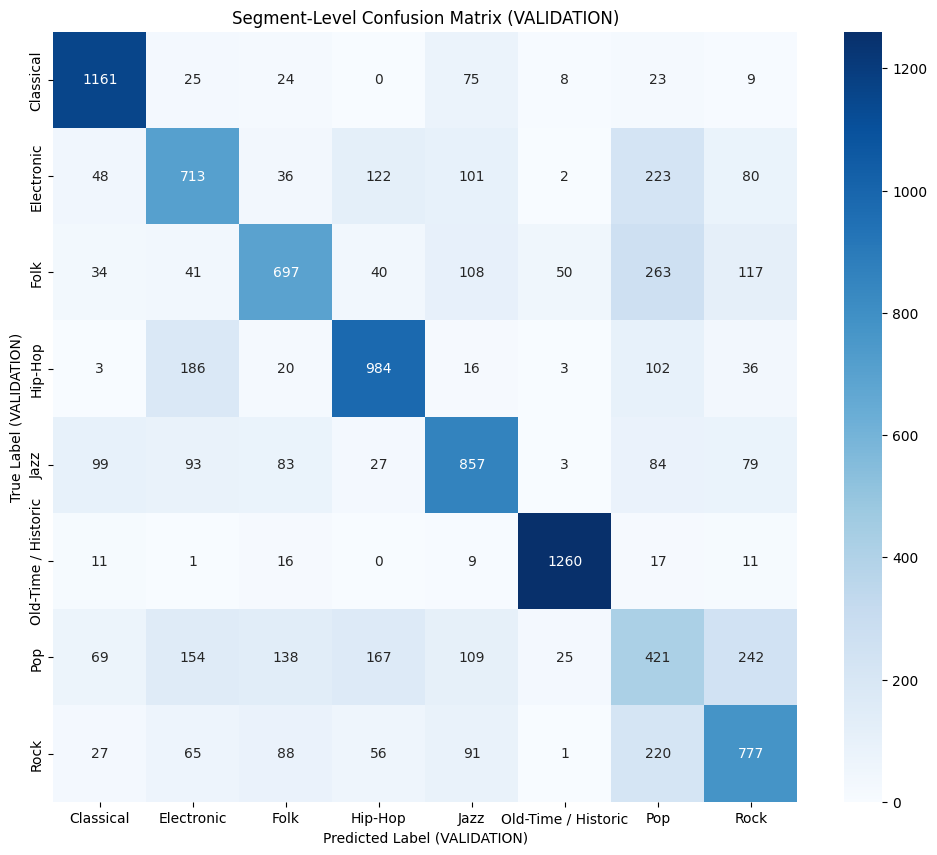


======== TRACK-LEVEL EVALUATION: VALIDATION | Majority Voting ========
Accuracy: 0.7112676056338029
Balanced Accuracy: 0.7114343116701607
Macro F1: 0.7093113547402297

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.82      0.92      0.87        53
         Electronic       0.60      0.66      0.63        53
               Folk       0.74      0.59      0.66        54
            Hip-Hop       0.77      0.76      0.77        54
               Jazz       0.84      0.79      0.82        53
Old-Time / Historic       0.95      0.98      0.96        53
                Pop       0.33      0.32      0.32        53
               Rock       0.64      0.66      0.65        53

           accuracy                           0.71       426
          macro avg       0.71      0.71      0.71       426
       weighted avg       0.71      0.71      0.71       426

Saved majority-voting track predictions to: Results/PANN_25x3s_MLP_valida

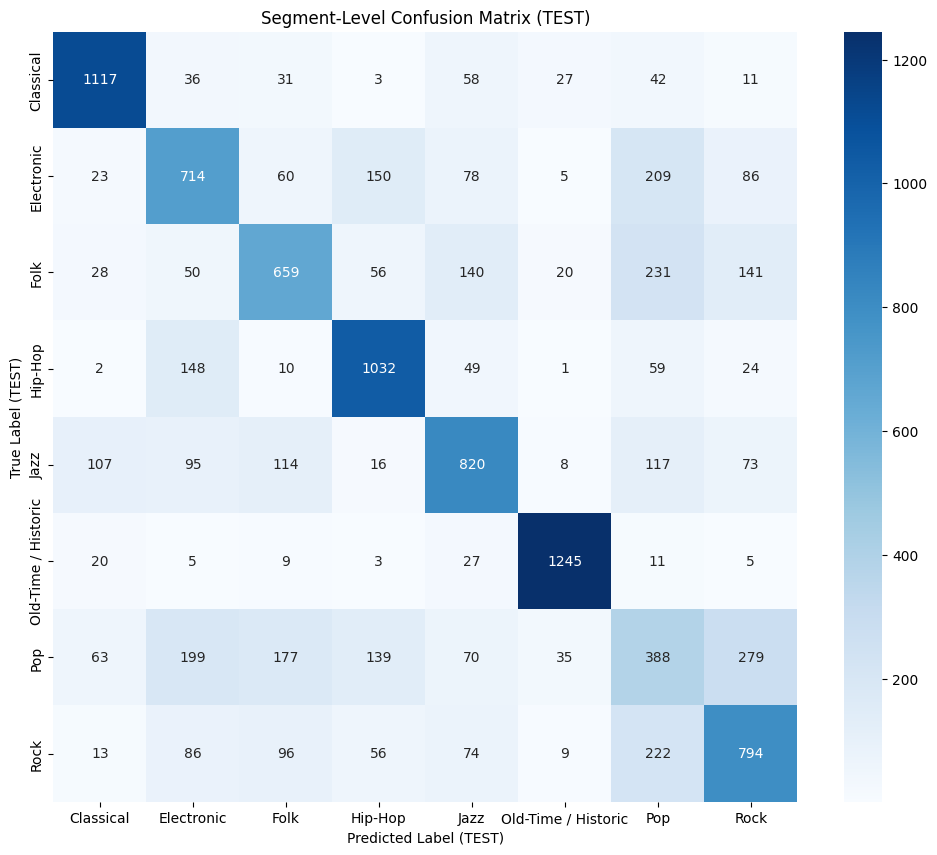


======== TRACK-LEVEL EVALUATION: TEST | Majority Voting ========
Accuracy: 0.7447306791569087
Balanced Accuracy: 0.7459381551362684
Macro F1: 0.735576729403203

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.86      0.94      0.90        53
         Electronic       0.67      0.75      0.71        53
               Folk       0.67      0.60      0.63        53
            Hip-Hop       0.78      0.94      0.85        53
               Jazz       0.81      0.70      0.75        54
Old-Time / Historic       0.98      1.00      0.99        53
                Pop       0.42      0.30      0.35        54
               Rock       0.67      0.72      0.70        54

           accuracy                           0.74       427
          macro avg       0.73      0.75      0.74       427
       weighted avg       0.73      0.74      0.73       427

Saved majority-voting track predictions to: Results/PANN_25x3s_MLP_test_track_le

,track_id,segment_id,true_genre,predicted_genre
0,58945,10,Classical,Jazz
1,58945,13,Classical,Pop
2,58945,19,Classical,Jazz
3,58945,20,Classical,Pop
4,58945,24,Classical,Pop


In [ ]:
# ---------------------------------------------------------
# TRAIN MLP ON PANN 25x3s SEGMENT FEATURES
# ---------------------------------------------------------

from sklearn.neural_network import MLPClassifier

MODEL_OUTPUT_NAME = "PANN_3s_25_MLP"

clf = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation="relu",
    solver="adam",
    alpha=1e-5,
    batch_size=64,
    learning_rate="adaptive",
    learning_rate_init=1e-4,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
    verbose=True
)

print("Starting MLP training...")
clf.fit(X_train_scaled, y_train)
print("Training completed.")

model_path = os.path.join(
    trained_models_dir,
    f"{MODEL_OUTPUT_NAME}.joblib"
)

joblib.dump(clf, model_path)
print(f"Saved model to {model_path}")

# Validation evaluation on segment level
y_val_pred = evaluate_model(clf, X_val_scaled, y_val, "VALIDATION", label_encoder)

# Validation evaluation on track level
track_level_val_results = evaluate_track_level(
    model=clf,
    X_data=X_val_scaled,
    y_true=y_val,
    track_ids=split_features["val"]["track_ids"],
    set_name="VALIDATION",
    label_encoder=label_encoder,
    output_name=MODEL_OUTPUT_NAME
)

# Final test evaluation on segment level
y_test_pred = evaluate_model(clf, X_test_scaled, y_test, "TEST", label_encoder)

# Final test evaluation on track level
track_level_test_results = evaluate_track_level(
    model=clf,
    X_data=X_test_scaled,
    y_true=y_test,
    track_ids=track_ids_test,
    set_name="TEST",
    label_encoder=label_encoder,
    output_name=MODEL_OUTPUT_NAME
)

misclassified_samples = save_misclassified_samples(y_test_pred, MODEL_OUTPUT_NAME)
misclassified_samples.head()